# 04: Main Model, Fine-Tuning ModernBERT

`answerdotai/ModernBERT-base` (2024 encoder, native long context) with a
classification head. AdamW, linear warmup and decay, inverse-frequency weighted
cross-entropy for imbalance, bf16 mixed precision, gradient accumulation for
the 12 GB RTX 3080 Ti, early stopping on validation macro-F1.

> GPU training. A full run takes tens of minutes per configuration.

In [1]:
import json
from torch.utils.data import DataLoader
import torch.nn as nn
from transformers import DataCollatorWithPadding

from wcc.data import PROCESSED_DIR, load_processed
from wcc.datasets import TransformerTextDataset
from wcc.metrics import (
    compute_metrics,
    confusion,
    plot_confusion_matrix,
    plot_per_class_f1,
    plot_training_curves,
    print_report,
)
from wcc.train import ARTIFACTS, _evaluate_transformer, get_device, train_transformer

train, val, test, label_map = load_processed()
label_names = [k for k, _ in sorted(label_map.items(), key=lambda kv: kv[1])]
RESULTS_DIR = ARTIFACTS / "results"; RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = ARTIFACTS.parent / "figures"; FIG_DIR.mkdir(parents=True, exist_ok=True)

tr_args = (train["content"].tolist(), train["label"].tolist(),
           val["content"].tolist(), val["label"].tolist(), label_names)

## Fine-tune

`freeze='full'` fine-tunes the entire encoder plus the classification head,
the highest-scoring setup and within the 12 GB budget at this batch size. The
frozen and last-N alternatives are compared in notebook 05.

In [2]:
import statistics

FINAL_CONFIG = dict(
    max_length=1024,         # nb05 ablation winner: sequence_length
    lr=5e-5,                 # nb05 ablation winner: learning_rate
    pooling="cls",           # nb05 ablation winner: pooling
    use_class_weights=True,  # nb05 ablation winner: class_weighting
    freeze="full",           # nb05 ablation winner: fine-tuning depth
)
SEEDS = (42, 43, 44)
TRAIN_KW = dict(epochs=5, batch_size=8, grad_accum=2, **FINAL_CONFIG)

seed_runs = []
for s in SEEDS:
    model, tokenizer, hist = train_transformer(
        *tr_args,
        seed=s,
        verbose=(s == SEEDS[0]),
        save_dir=ARTIFACTS / "modernbert" if s == SEEDS[0] else None,
        **TRAIN_KW,
    )
    test_loader = DataLoader(
        TransformerTextDataset(test["content"].tolist(), test["label"].tolist(),
                               tokenizer, FINAL_CONFIG["max_length"]),
        batch_size=16, collate_fn=DataCollatorWithPadding(tokenizer),
    )
    yt_s, yp_s, _ = _evaluate_transformer(model, test_loader, get_device(),
                                          nn.CrossEntropyLoss())
    m_s = compute_metrics(yt_s, yp_s, label_names)
    seed_runs.append({"seed": s, "metrics": m_s, "history": hist,
                      "y_true": yt_s, "y_pred": yp_s})
    print(f"seed {s}: test macro-F1 = {m_s['macro_f1']:.4f}  "
          f"acc = {m_s['accuracy']:.4f}")

# Seed 42 is the reference run (saved checkpoint, plotted curves and confusion).
ref = seed_runs[0]
history = ref["history"]
for h in history:
    print(h)

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ModernBERT: 149,624,089 trainable params (freeze=full, pooling=cls, max_length=1024)


epoch 1:   0%|          | 0/792 [00:00<?, ?it/s]

epoch 1  train_loss 2.5947  val_loss 1.9324  val_macroF1 0.4924  val_acc 0.5440


...

[transformers] ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


seed 43: test macro-F1 = 0.5052  acc = 0.5554


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


seed 44: test macro-F1 = 0.5031  acc = 0.5708
{'epoch': 1, 'train_loss': 2.594687851787141, 'val_loss': 1.932386338710785, 'val_macro_f1': 0.49236989865979003, 'val_accuracy': 0.5440340909090909, 'seconds': 202.4}
{'epoch': 2, 'train_loss': 1.6378382504249929, 'val_loss': 1.809158549390056, 'val_macro_f1': 0.5304809223345714, 'val_accuracy': 0.5894886363636364, 'seconds': 201.4}
{'epoch': 3, 'train_loss': 1.0090717506169595, 'val_loss': 1.9595338822427122, 'val_macro_f1': 0.5335224018818939, 'val_accuracy': 0.578125, 'seconds': 201.5}
{'epoch': 4, 'train_loss': 0.38895019717792206, 'val_loss': 2.4552614108066666, 'val_macro_f1': 0.5310155741347605, 'val_accuracy': 0.5823863636363636, 'seconds': 200.9}
{'epoch': 5, 'train_loss': 0.09540023410146255, 'val_loss': 2.680463633584705, 'val_macro_f1': 0.5291456512056711, 'val_accuracy': 0.5852272727272727, 'seconds': 202.1}


## Training curves

Train/validation loss and validation macro-F1 per epoch. Validation macro-F1
peaks early and then declines as the model overfits, so early stopping keeps the
best checkpoint (marked in red).

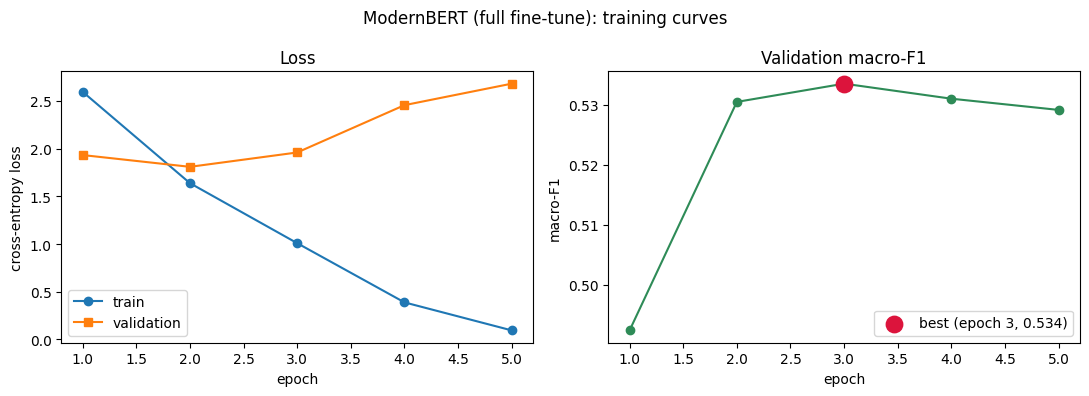

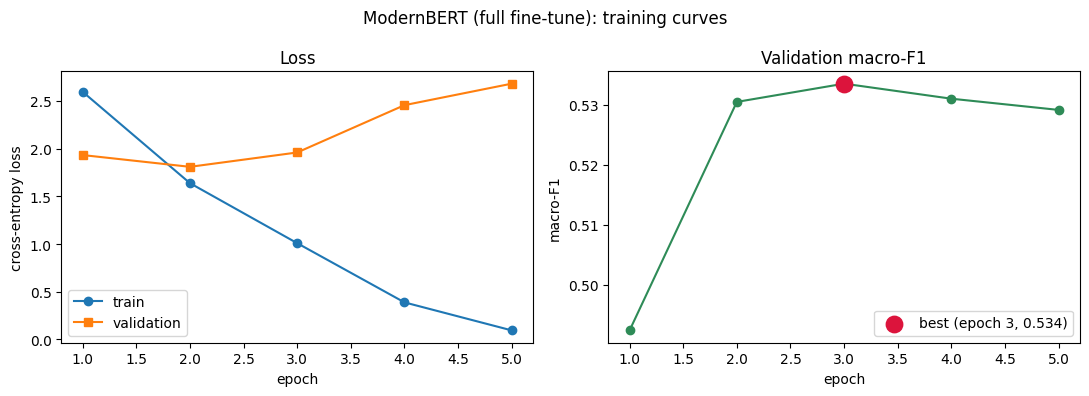

In [3]:
plot_training_curves(
    history,
    "ModernBERT (full fine-tune): training curves",
    save_path=FIG_DIR / "training_curves_modernbert.png",
)

## Held-out test evaluation: mean +/- std over three seeds

The headline number is the mean test macro-F1 across the three seeds. The
per-class table and confusion matrix below are from the seed-42 reference run.

In [4]:
yt, yp = ref["y_true"], ref["y_pred"]
test_metrics = compute_metrics(yt, yp, label_names)
print_report(test_metrics, "ModernBERT (seed 42 reference): TEST")

f1s = [r["metrics"]["macro_f1"] for r in seed_runs]
accs = [r["metrics"]["accuracy"] for r in seed_runs]
mean_f1, std_f1 = statistics.mean(f1s), statistics.pstdev(f1s)
mean_acc, std_acc = statistics.mean(accs), statistics.pstdev(accs)
print(f"3-seed test macro-F1 = {mean_f1:.4f} +/- {std_f1:.4f}   "
      f"accuracy = {mean_acc:.4f} +/- {std_acc:.4f}")

(RESULTS_DIR / "modernbert.json").write_text(json.dumps(
    {"model": "modernbert",
     "config": FINAL_CONFIG,
     "seeds": list(SEEDS),
     "test_macro_f1_seeds": f1s,
     "test_macro_f1": mean_f1,
     "test_macro_f1_std": std_f1,
     "test_accuracy": mean_acc,
     "test_accuracy_std": std_acc,
     "per_class": test_metrics["per_class"]}, indent=2))


=== ModernBERT (seed 42 reference): TEST ===
  accuracy    : 0.5582
  macro-F1    : 0.5123
  weighted-F1 : 0.5656
  class                           P       R      F1      n
  News_and_Media              0.175   0.159   0.167     63
  Adult                       1.000   0.100   0.182     20
  Arts_and_Entertainment      0.176   0.325   0.228     40
  Home_and_Garden             0.211   0.267   0.235     15
  Internet_and_Telecom        0.321   0.321   0.321     78
  Career_and_Education        0.278   0.478   0.352     46
  Shopping                    0.329   0.481   0.391     52
  Business_and_Industry       0.457   0.390   0.421     82
  Recreation_and_Hobbies      0.365   0.500   0.422     38
  Computer_and_Electronics    0.478   0.493   0.485     67
  Science                     0.440   0.597   0.506     67
  People_and_Society          0.520   0.510   0.515    100
  Travel                      0.590   0.575   0.582     40
  Games                       0.614   0.574   0.593     47


4315

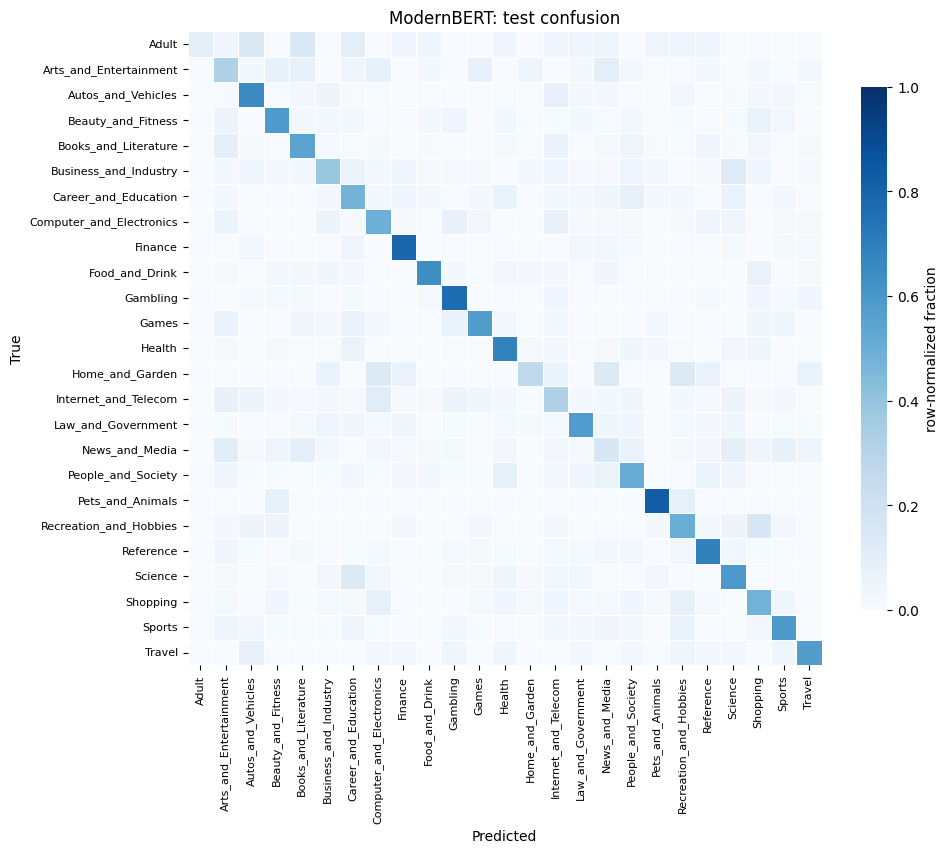

In [5]:
cm = confusion(yt, yp, len(label_names))
ax = plot_confusion_matrix(cm, label_names, "ModernBERT: test confusion")
ax.figure.tight_layout()
ax.figure.savefig(FIG_DIR / "confusion_modernbert.png", dpi=150)

## Per-class F1

Where the model is strong and where it is weak. Small classes (low `n`) and
semantically broad categories sit below the macro-F1 line.

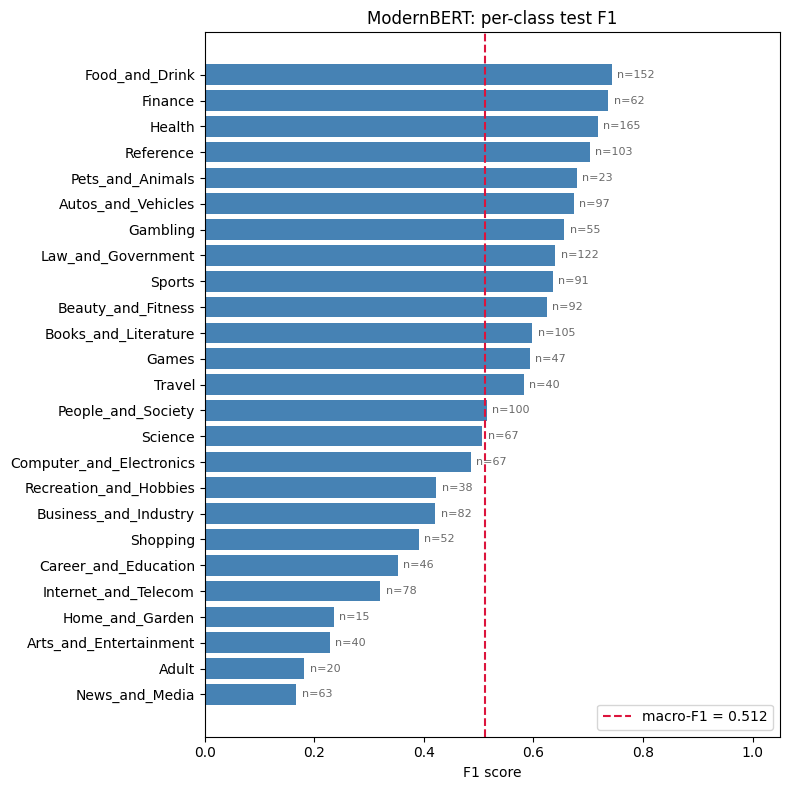

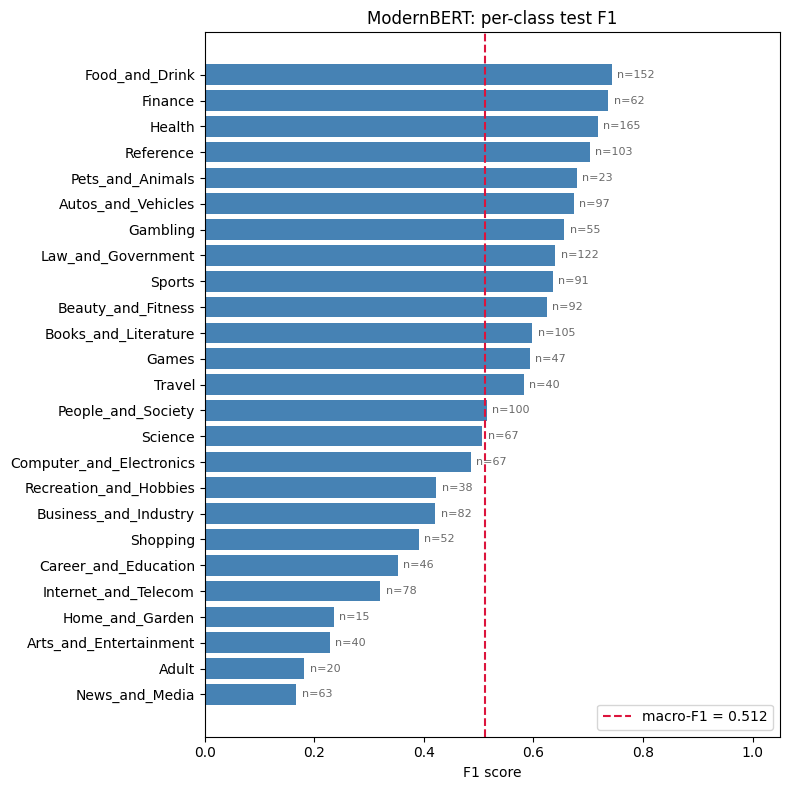

In [6]:
plot_per_class_f1(
    test_metrics["per_class"],
    "ModernBERT: per-class test F1",
    save_path=FIG_DIR / "per_class_f1.png",
)

## Takeaway

Large-scale pre-training transfers, so ModernBERT is expected to clear both the
TF-IDF baseline and the from-scratch model. Residual errors concentrate in
semantically adjacent classes (Business and Career, Reference and Science) and
are partly bounded by single-source label noise. See notebook 05.